In [1]:
# Imports + session load. All real work lives in helpers.py.
import numpy as np
import matplotlib.pyplot as plt
from helpers import (
    load_eeg_demg_recording, subtract_common_reference, filter_eeg,
    bandpass_filter_emg, build_eeg_demg_stack, build_stim_trial_table,
    extract_trial_windows, compute_trial_psds, build_band_power_dataframe,
    plot_continuous_with_events, plot_post_band_power_scatter,
    plot_band_power_heatmaps, plot_pre_post_bars, plot_normalized_bars,
    plot_average_psd, plot_pre_delta_regression, compute_windowed_features,
    plot_windowed_band_power, make_eeg_demg_trial_viewer, EEG_BANDS,
)
from IPython.display import display

# Channel layout (varies by rat):
#   0: None / 1: EEG 1 / 2: EEG 2 / 3: EEG 3 (common reference)
#   4: dEMG 1 / 5: dEMG 2 / 6-8: ADC1-3
EEG_TARGET_COLS = [1, 2]      # EEG channels to subtract reference from
EEG_REF_COL     = 3           # common-reference channel
EEG_ALL_COLS    = [1, 2, 3]   # all 3 EEG channels (filtered + shown in viewer)
DEMG1_COL, DEMG2_COL = 4, 5

directory = 'dEMGPilot3-4-9-26'
bundle = load_eeg_demg_recording(directory)


Session: dEMGPilot3-4-9-26
Loaded:  dEMGPilot3-4-9-26\Record Node 101\experiment2\recording1
  record node: Record Node 101
  experiment:  experiment2
  recording:   recording1
Sample rate: 5000.0 Hz
Channels (9): ['CH1', 'CH5', 'CH7', 'CH8', 'CH10', 'CH12', 'ADC1', 'ADC2', 'ADC3']
Data shape: (4897763, 9)
Loaded 0 MessageCenter entries from dEMGPilot3-4-9-26\Record Node 101\experiment2\recording1\events\MessageCenter
Unique TTL lines: [1 3]
Total events: 84  |  VNS: 24  |  Sham: 18


In [2]:
# EEG: ref-subtract (cols 1,2 - col 3) + 60 Hz notch + 0.5 Hz HP across all 3 EEG cols.
data_refsub = subtract_common_reference(bundle['data'],
                                        target_cols=EEG_TARGET_COLS,
                                        ref_col=EEG_REF_COL)
data_filt   = filter_eeg(data_refsub, bundle['samplerate'], cols=EEG_ALL_COLS)

# dEMG: 100-1000 Hz bandpass; bipolar = dEMG2 - dEMG1.
demg1, demg2, demg_bipolar = bandpass_filter_emg(
    bundle['data'], ch1_idx=DEMG1_COL, ch2_idx=DEMG2_COL,
    sample_rate=bundle['samplerate'])

# (n_samples, 4) stack used by trial windows + viewer:
#   col 0 = EEG 1 / col 1 = EEG 2 / col 2 = EEG 3 (ref) / col 3 = bipolar dEMG
viewer_data = build_eeg_demg_stack(data_filt, demg_bipolar, eeg_cols=EEG_ALL_COLS)


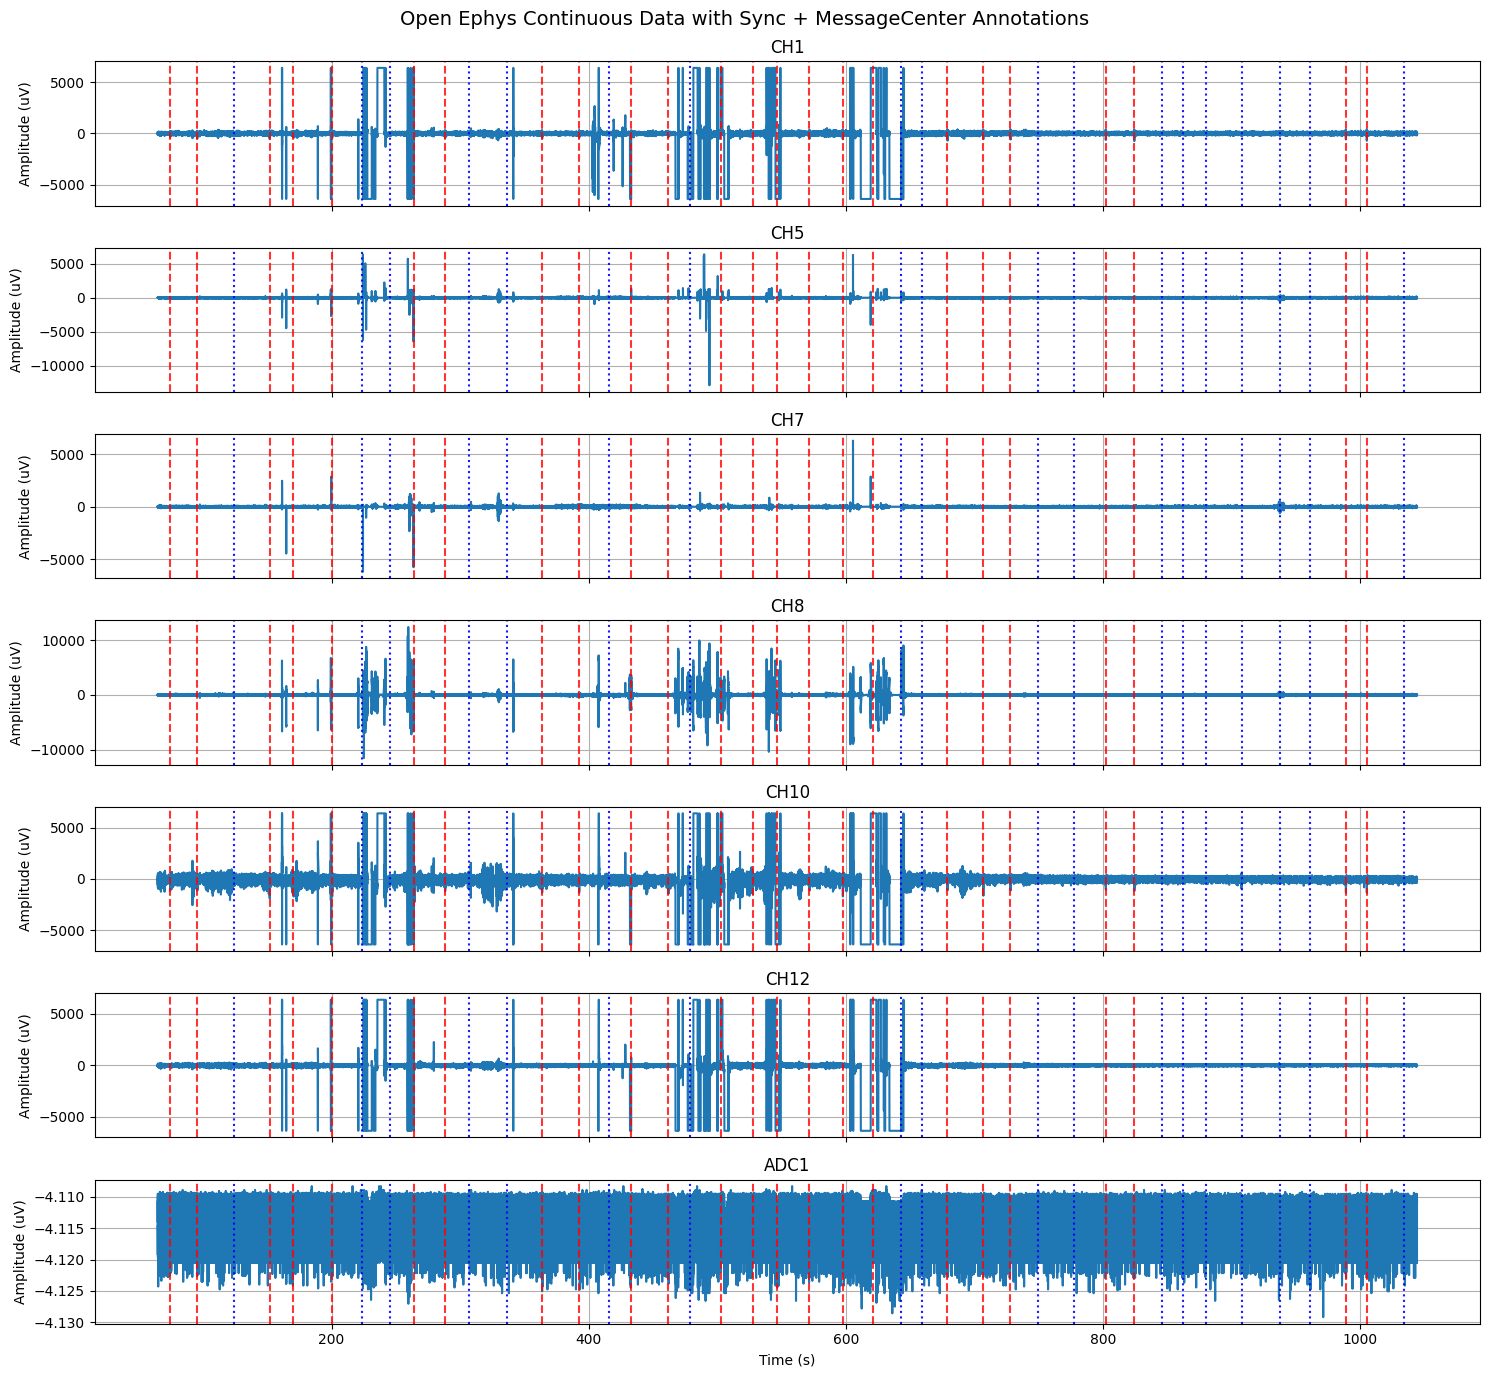

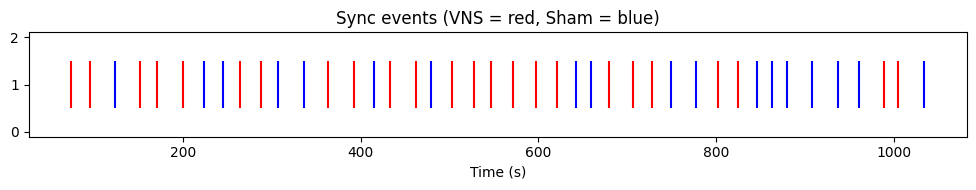

In [3]:
# Stacked per-channel continuous plot with VNS / Sham / MessageCenter overlays.
plot_continuous_with_events(bundle, data_filt)


In [4]:
trial_table = build_stim_trial_table(bundle)
all_trials  = extract_trial_windows(
    trial_table, bundle['timestamps'], viewer_data,
    pre_time=5, post_time=15, stimulation_duration=1)
# PSD / band power on EEG cols only (cols 0,1,2 of the viewer stack).
compute_trial_psds(all_trials, bundle['samplerate'],
                   eeg_bands=EEG_BANDS, psd_cols=[0, 1, 2])
df_power = build_band_power_dataframe(all_trials, EEG_BANDS)

vns_n  = sum(t['type'] == 'VNS'  for t in all_trials)
sham_n = sum(t['type'] == 'SHAM' for t in all_trials)
print(f"{len(all_trials)} trials  ({vns_n} VNS / {sham_n} SHAM)")


42 trials  (24 VNS / 18 SHAM)


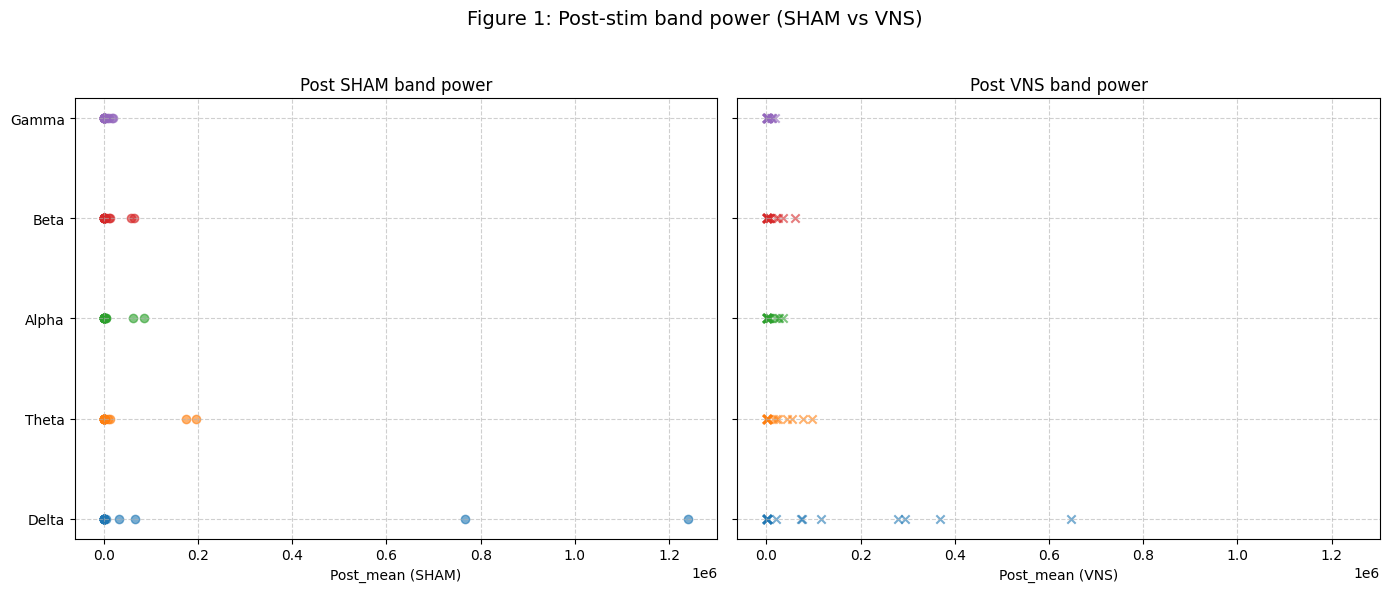

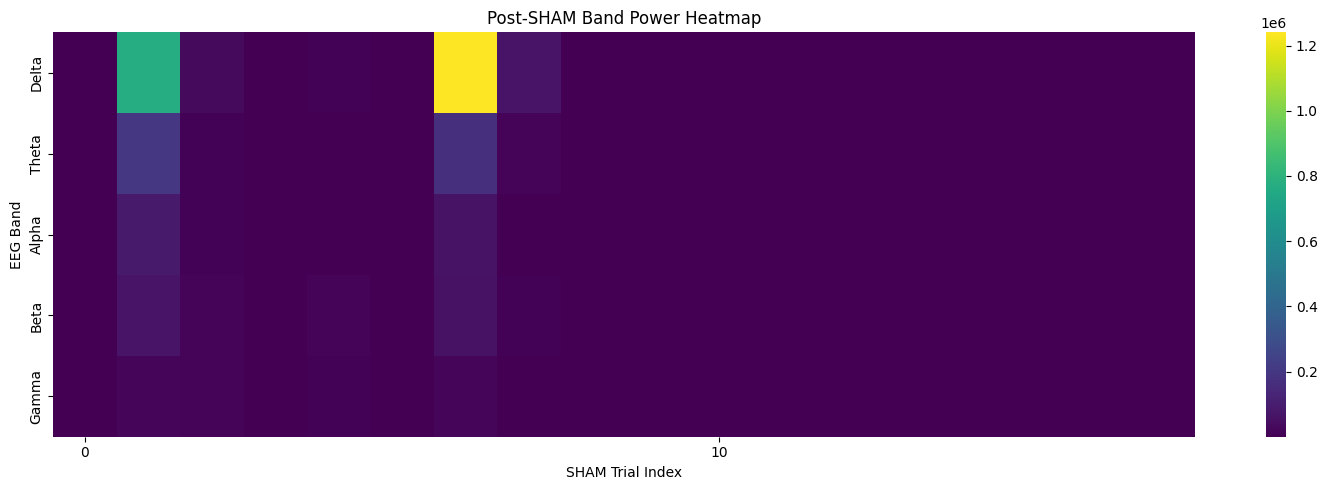

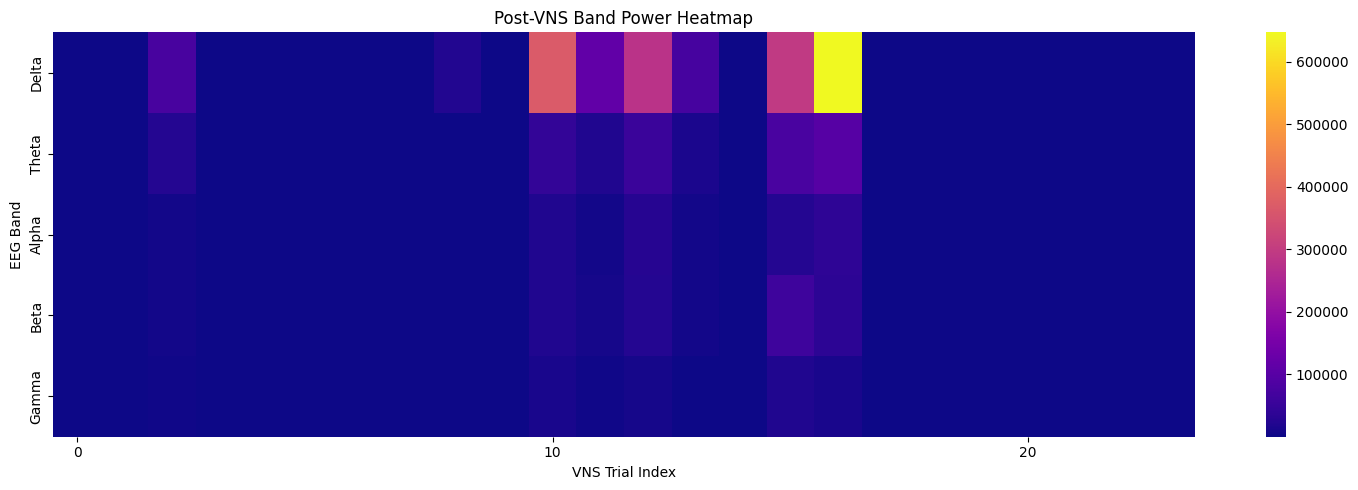

In [5]:
# Figure 1: scatter of post band power for SHAM vs VNS.
post_sham, post_vns = plot_post_band_power_scatter(df_power)
# Figure 2a / 2b: per-trial heatmaps.
plot_band_power_heatmaps(post_sham, post_vns)


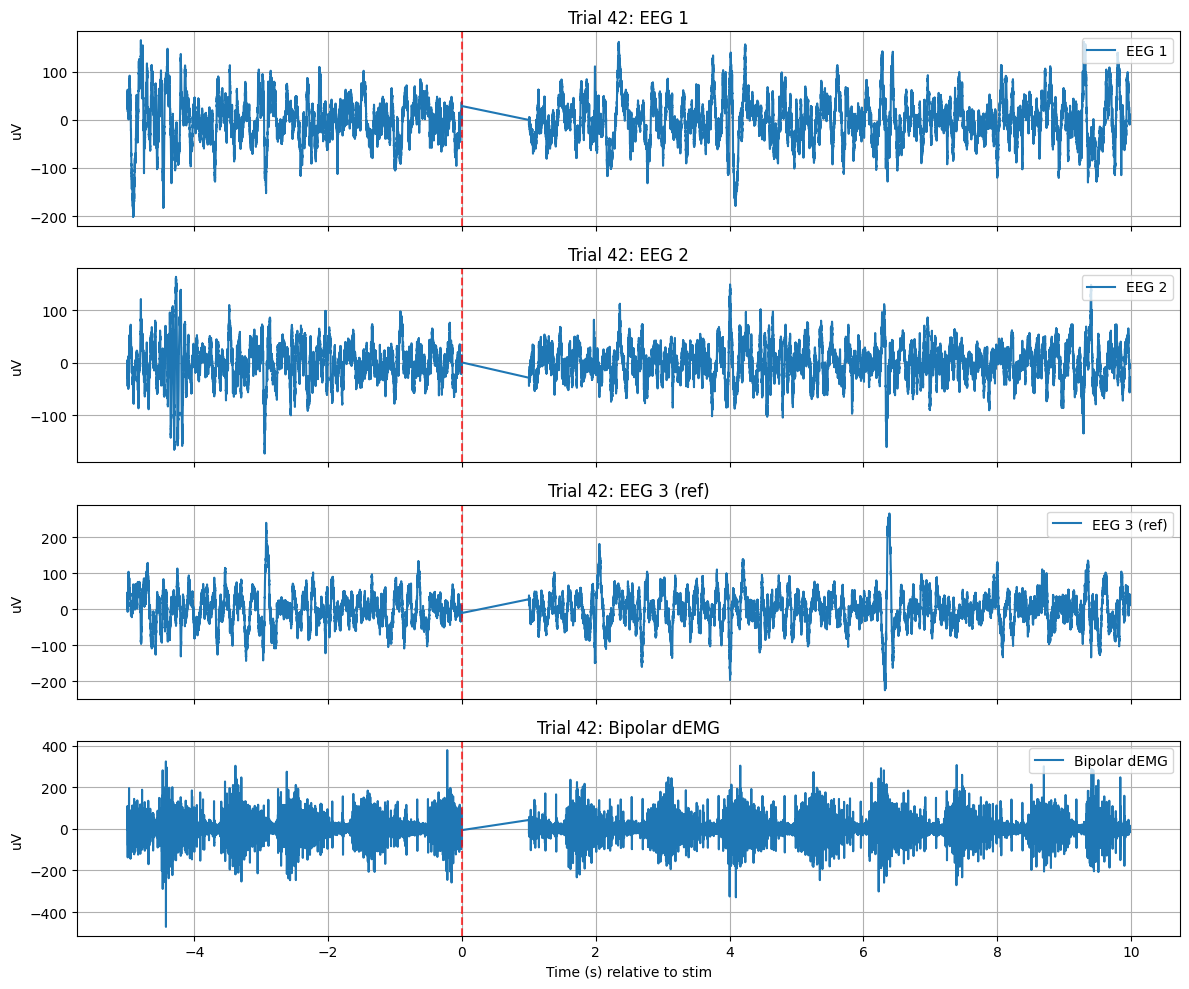

In [6]:
# Single-trial overview: pre + post stitched together, one row per channel.
single_trial_idx = min(89, len(all_trials) - 1)
trial = all_trials[single_trial_idx]

combined_t    = np.concatenate((trial['pre_timestamps'], trial['post_timestamps']))
combined_data = np.vstack((trial['pre_data'], trial['post_data']))
labels = ['EEG 1', 'EEG 2', 'EEG 3 (ref)', 'Bipolar dEMG']

n = combined_data.shape[1]
fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n), sharex=True)
for ch, ax in enumerate(axes):
    ax.plot(combined_t, combined_data[:, ch], label=labels[ch])
    ax.axvline(0, color='red', linestyle='--', alpha=0.7)
    ax.set_ylabel('uV')
    ax.set_title(f"Trial {trial['trial']}: {labels[ch]}")
    ax.grid(True); ax.legend(loc='upper right')
axes[-1].set_xlabel("Time (s) relative to stim")
plt.tight_layout()
plt.show()


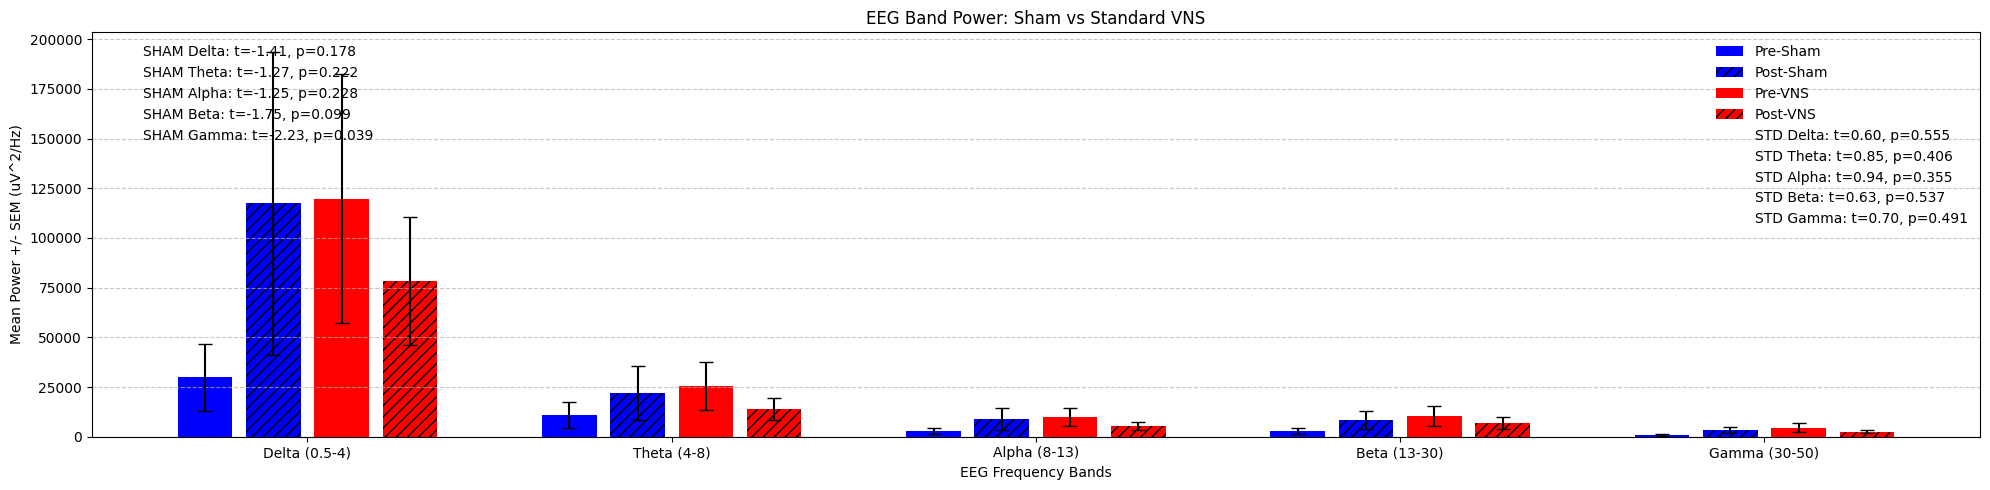

In [7]:
# Figure 4: pre-vs-post bars (SHAM/VNS) with paired t-test stats in the legend.
plot_pre_post_bars(df_power)


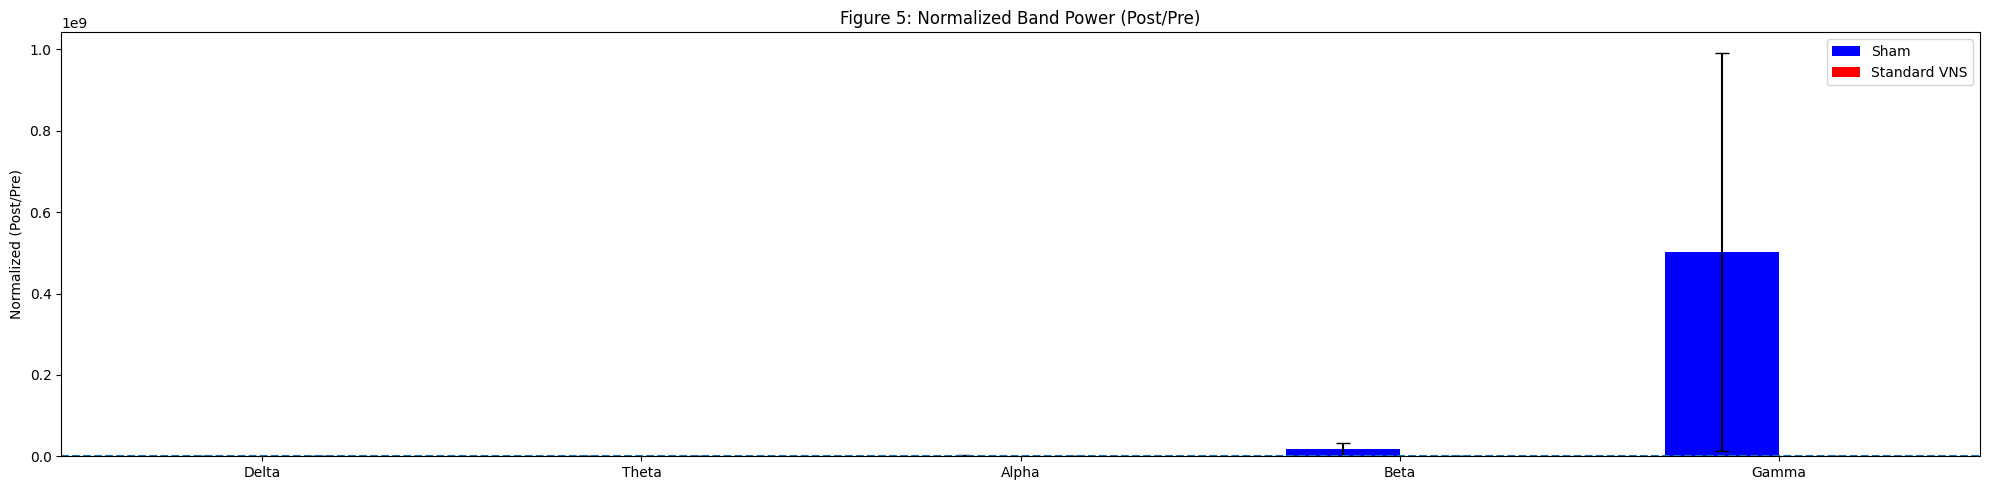

In [8]:
# Figure 5: normalized (post / pre) band power, SHAM vs VNS.
plot_normalized_bars(df_power)


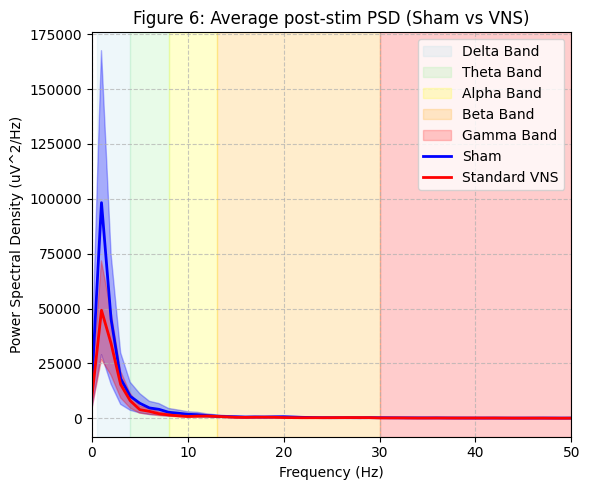

In [9]:
# Figure 6: average per-trial PSD across channels for SHAM vs VNS.
plot_average_psd(all_trials, phase='post')


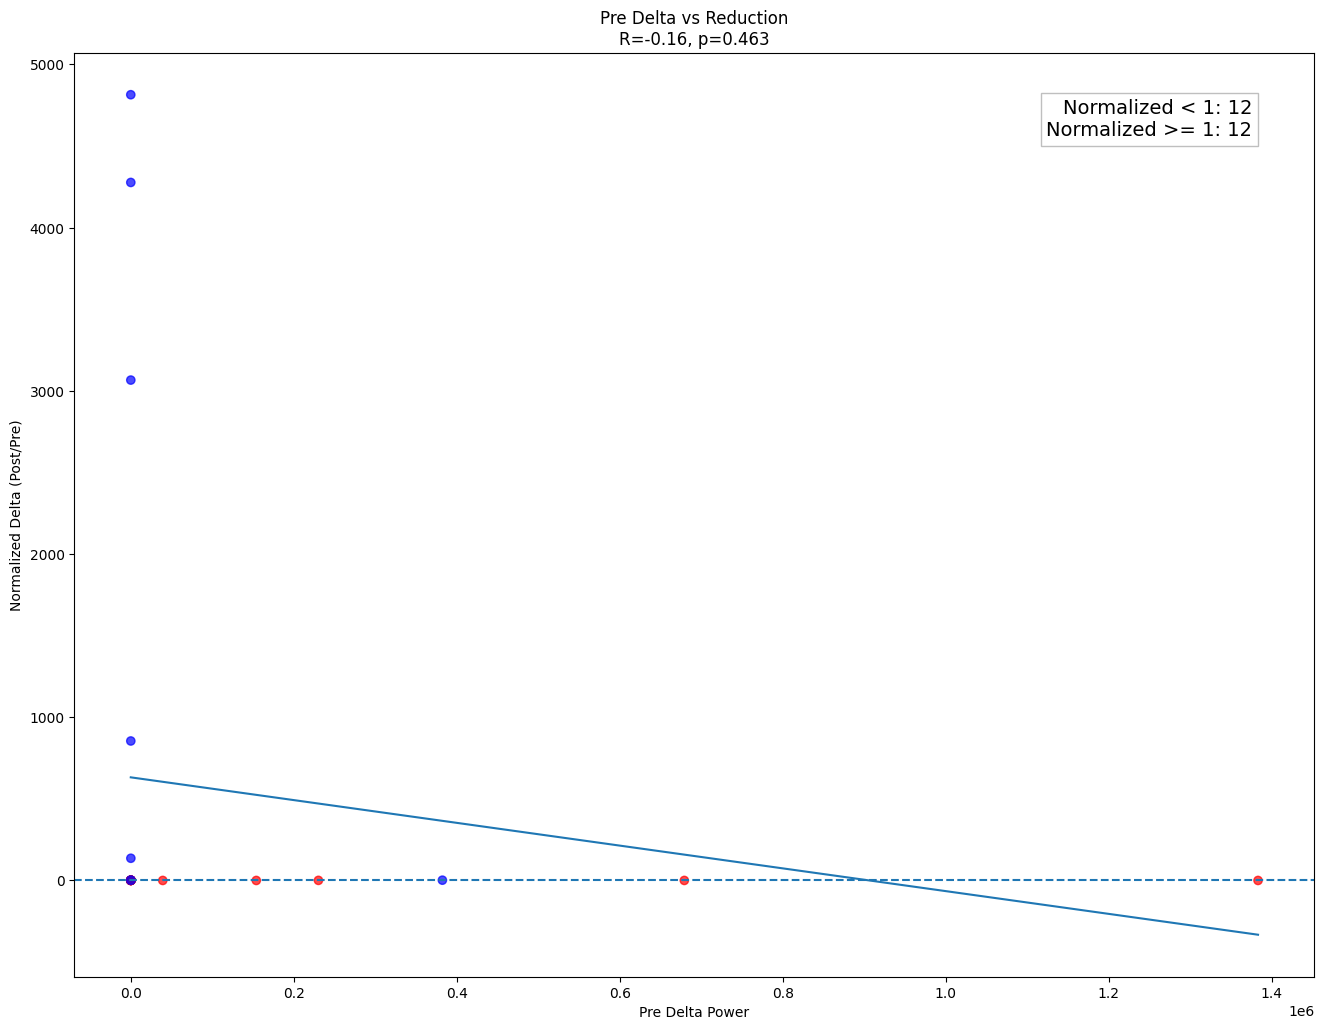

In [10]:
# Figure 8: regression of pre-band power vs post/pre ratio (VNS only).
plot_pre_delta_regression(all_trials, band='Delta')


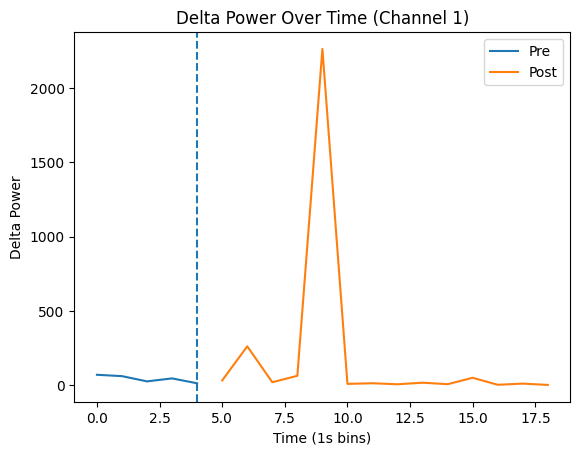

In [11]:
# 1-second windowed features for one trial, then plot the chosen band/channel.
features = compute_windowed_features(
    all_trials[min(11, len(all_trials) - 1)],
    bundle['samplerate'], EEG_BANDS, psd_cols=[0, 1, 2])
plot_windowed_band_power(features, band='Delta', channel=1)


In [12]:
# Figure 10: interactive trial viewer.
# 4 panels per trial: 3 EEG channels + bipolar dEMG.
# Pre / Post analysis windows drive the second-figure PSD/Power grid.
display(make_eeg_demg_trial_viewer(
    all_trials,
    samplerate=bundle['samplerate'],
    eeg_labels=['EEG 1', 'EEG 2', 'EEG 3 (ref)'],
    demg_label='Bipolar dEMG (dEMG2-dEMG1)',
    stimulation_duration=1.0,
))


Loaded 42 trials. Use Prev/Next or the dropdown to navigate.
